# Physics-Informed Binding Affinity

| Stage | Tool |
|---|---|
| Data | **TDC** `BindingDB_Kd` |
| Splits + eval | Manual scaffold split + sklearn metrics |
| Ligand encoder | **ChemProp 2.x** (D-MPNN) |
| Protein encoder | **ESM-C 300M** (EvolutionaryScale) |
| Physics features | **RDKit** |
| Uncertainty | Deep ensemble + **uncertainty-toolbox** |


In [ ]:
import sys, subprocess

def pip_install(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=False)

pip_install('--upgrade', '--force-reinstall', '--no-deps', 'pyarrow>=18,<21')

pip_install('PyTDC', 'chemprop>=2.0', 'esm>=3.0',
            'rdkit', 'uncertainty-toolbox', 'tqdm',
            'scikit-learn>=1.4')

print("Install done. Killing kernel so pyarrow reloads cleanly.")
print("=> When Kaggle reconnects, run from Cell 2 (skip this cell).")

import os
os.kill(os.getpid(), 9)

In [1]:
import warnings; warnings.filterwarnings('ignore')
from collections import defaultdict
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Stitched components
from tdc.multi_pred import DTI
from huggingface_hub import login as hf_login
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from chemprop.data import MoleculeDatapoint, MoleculeDataset, BatchMolGraph
from chemprop.featurizers import SimpleMoleculeMolGraphFeaturizer
from chemprop.nn import BondMessagePassing, MeanAggregation
import uncertainty_toolbox as uct

torch.manual_seed(0); np.random.seed(0)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: cuda


## Stage 1 — Data via TDC + scaffold split

`tdc.multi_pred.DTI(name='BindingDB_Kd')` gives ~50K (SMILES, protein_seq, Kd) triplets.
We:
1. Subsample to 5K for MVP speed (remove `.sample(...)` for full run)
2. Convert Kd to pK = −log10(Kd) for a reasonable regression target
3. Apply Bemis-Murcko **scaffold split** (80/10/10) — much harder than random and closer to
   the realistic deployment setting where you must generalize to new chemical series

If you want random split for comparison, replace `scaffold_split` with `random_split` below.


In [2]:
DATASET_NAME = 'BindingDB_Kd'        # 'BindingDB_Ki', 'DAVIS', 'KIBA' 
N_SUBSAMPLE  = 5000                

raw = DTI(name=DATASET_NAME).get_data() # Load dataset DTI
print(f"Raw {DATASET_NAME}: {len(raw)} pairs")
print(f"Raw columns: {list(raw.columns)}")

# Standardize column names: TDC gives Drug (SMILES), Target (sequence), Y (raw value)
df = raw.rename(columns={'Drug': 'smiles', 'Target': 'sequence', 'Y': 'y_raw'})
df = df[['smiles', 'sequence', 'y_raw']].dropna().reset_index(drop=True)

# Convert Kd (nM) -> pKd. BindingDB_Kd in TDC is in nM.
# pKd = -log10(Kd in M) = -log10(Kd_nM * 1e-9) = 9 - log10(Kd_nM)
df['y'] = 9.0 - np.log10(df['y_raw'].clip(lower=1e-3))
df = df.drop(columns=['y_raw'])

# select 5000 samples for fast training
if N_SUBSAMPLE and len(df) > N_SUBSAMPLE:
    df = df.sample(n=N_SUBSAMPLE, random_state=42).reset_index(drop=True)
print(f"After subsample: {len(df)}")
print(f"pKd: mean={df['y'].mean():.2f}  std={df['y'].std():.2f}  "
      f"range=[{df['y'].min():.2f}, {df['y'].max():.2f}]")

# ---- Scaffold split ----
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return ''
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

def scaffold_split(df, frac_train=0.8, frac_val=0.1):
    groups = defaultdict(list)
    for i, smi in enumerate(df['smiles']):
        groups[get_scaffold(smi)].append(i)
    sets = sorted(groups.values(), key=len, reverse=True)
    n = len(df)
    n_tr, n_va = int(n * frac_train), int(n * frac_val)
    tr, va, te = [], [], []
    for s in sets:
        if len(tr) + len(s) <= n_tr:        tr.extend(s)
        elif len(va) + len(s) <= n_va:      va.extend(s)
        else:                                te.extend(s)
    return np.array(tr), np.array(va), np.array(te)

tr_idx, va_idx, te_idx = scaffold_split(df)
print(f"Scaffold split: train={len(tr_idx)}  val={len(va_idx)}  test={len(te_idx)}")
print(f"Unique scaffolds: {len(set(get_scaffold(s) for s in df['smiles']))}")

train_df = df.iloc[np.concatenate([tr_idx, va_idx])].reset_index(drop=True)  # train+val for ESM-C cache
test_df  = df.iloc[te_idx].reset_index(drop=True)
# Track which rows of train_df correspond to val (for early stopping later)
val_mask = np.zeros(len(train_df), dtype=bool); val_mask[len(tr_idx):] = True

Found local copy...
Loading...
Done!


Raw BindingDB_Kd: 52274 pairs
Raw columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y']
After subsample: 5000
pKd: mean=5.86  std=1.37  range=[2.00, 12.00]
Scaffold split: train=4000  val=500  test=500
Unique scaffolds: 1174


## Stage 2 — Featurize each modality

Three streams, computed once and cached:

1. **Ligand** → ChemProp `MolGraph` (precomputed, batched at training time)
2. **Protein** → ESM-C 300M mean-pooled embedding (frozen, deduplicated by sequence)
3. **Physics** → 14 RDKit descriptors (LogP / TPSA / etc.)

ESM-C's SDK API processes one protein at a time, so deduplication by unique sequence
is not optional — it's what makes this tractable.


In [3]:
# ESM-C from EvolutionaryScale. Requires HuggingFace token.
# multi-modal generation, but for embedding-only this is the right choice.

ESM_MODEL = 'esmc_300m'   # 'esmc_300m' (960-dim) | 'esmc_600m' (1152-dim)
ESM_DIM   = 960           # update to 1152 if using esmc_600m

# --- HF login: try Kaggle Secrets first, fall back to interactive ---
def hf_authenticate():
    # Path 1: Kaggle Secrets (Add-ons > Secrets > HF_TOKEN)
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret('HF_TOKEN')
        hf_login(token=token, add_to_git_credential=False)
        print("HF login: Kaggle Secret HF_TOKEN ✓")
        return
    except Exception as e:
        print(f"Kaggle Secrets path skipped ({type(e).__name__})")
    # Path 2: env var
    import os
    if os.environ.get('HF_TOKEN'):
        hf_login(token=os.environ['HF_TOKEN'], add_to_git_credential=False)
        print("HF login: HF_TOKEN env var ✓")
        return
    # Path 3: interactive
    hf_login()

hf_authenticate()

print(f"Loading {ESM_MODEL}...")
esm_model = ESMC.from_pretrained(ESM_MODEL).to(DEVICE).eval()
for p in esm_model.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def embed_proteins(seqs, max_len=1022):
    out = np.zeros((len(seqs), ESM_DIM), dtype=np.float32)
    cfg = LogitsConfig(sequence=True, return_embeddings=True)
    for i, seq in enumerate(tqdm(seqs, desc='ESM-C')):
        protein = ESMProtein(sequence=seq[:max_len])
        tensor = esm_model.encode(protein)
        output = esm_model.logits(tensor, cfg)
        # output.embeddings: [1, L+2, D] — drop BOS/EOS, mean-pool over residues
        emb = output.embeddings[0, 1:-1].mean(dim=0)
        out[i] = emb.float().cpu().numpy()
    return out

unique_seqs = sorted(set(train_df['sequence']) | set(test_df['sequence']))
print(f"Unique protein sequences: {len(unique_seqs)}")
seq_emb = embed_proteins(unique_seqs)
seq2emb = {s: e for s, e in zip(unique_seqs, seq_emb)}

Kaggle Secrets path skipped (BackendError)


Loading esmc_300m...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Unique protein sequences: 788


ESM-C:   0%|          | 0/788 [00:00<?, ?it/s]

In [4]:
# ---------- ChemProp molecular graph featurizer ----------
mol_featurizer = SimpleMoleculeMolGraphFeaturizer()

def smi_to_molgraph(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return mol_featurizer(mol)

# ---------- RDKit physics descriptors (~MM/QM proxies) ----------
def physics_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.HeavyAtomCount(mol),
        Descriptors.RingCount(mol),
        Descriptors.NumAromaticRings(mol),
        Lipinski.FractionCSP3(mol),
        Crippen.MolMR(mol),
        Lipinski.NumHeteroatoms(mol),
        rdMolDescriptors.CalcNumAmideBonds(mol),
        rdMolDescriptors.CalcNumSpiroAtoms(mol),
    ], dtype=np.float32)

PHYS_DIM = 14

def featurize_df(df):
    keep, mgs, phys, prot, ys = [], [], [], [], []
    for i, row in df.iterrows():
        mg = smi_to_molgraph(row['smiles'])
        ph = physics_descriptors(row['smiles'])
        pe = seq2emb.get(row['sequence'])
        if mg is None or ph is None or pe is None:
            continue
        keep.append(i); mgs.append(mg); phys.append(ph); prot.append(pe); ys.append(row['y'])
    return {
        'orig_idx': np.array(keep),
        'mol_graphs': mgs,
        'phys': np.stack(phys),
        'prot': np.stack(prot),
        'y':    np.array(ys, dtype=np.float32),
    }

print("Featurizing train...");  train_data = featurize_df(train_df)
print("Featurizing test..."); test_data  = featurize_df(test_df)
print(f"Valid train: {len(train_data['y'])} / {len(train_df)}")
print(f"Valid test:  {len(test_data['y'])} / {len(test_df)}")

# Standardize physics features using train stats
phys_mean = train_data['phys'].mean(0)
phys_std  = train_data['phys'].std(0) + 1e-8
train_data['phys'] = (train_data['phys'] - phys_mean) / phys_std
test_data['phys']  = (test_data['phys']  - phys_mean) / phys_std

Featurizing train...
Featurizing test...
Valid train: 4500 / 4500
Valid test:  500 / 500


## Stage 3 — Multi-modal fusion model

ChemProp's `BondMessagePassing` is the trainable ligand encoder. ESM-C embedding
and physics features come in as fixed vectors. Concat → MLP → scalar.

This model is ~750K params trainable (vs ~300M for ESM-C, but ESM-C is frozen so only
the ligand MPNN + fusion head are trained).


In [5]:
class MultiModalAffinity(nn.Module):
    """
    Per-modality LayerNorm before concat — fixes magnitude mismatch
    between mol-graph (~0.1), protein embedding (~1+), physics (z-scored).
    mp_d_h: ChemProp molecular graph hidden dimension
    """
    def __init__(self, mp_d_h=300, prot_dim=ESM_DIM, phys_dim=PHYS_DIM,
                 hidden=384, dropout=0.25):
        super().__init__()
        self.mp  = BondMessagePassing(d_h=mp_d_h, depth=4)   # hidden dimension, pass 4 layers
        self.agg = MeanAggregation() # Average the representations of all nodes/bonds in the molecule to obtain a single molecule-level vector.

        # Per-modality projections + LayerNorm
        self.mol_proj  = nn.Sequential(nn.Linear(mp_d_h, 256), nn.LayerNorm(256), nn.ReLU())
        self.prot_proj = nn.Sequential(nn.Linear(prot_dim, 256), nn.LayerNorm(256), nn.ReLU())
        self.phys_proj = nn.Sequential(nn.Linear(phys_dim, 64), nn.LayerNorm(64), nn.ReLU())

        in_dim = 256 + 256 + 64
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, bmg, prot_emb, phys):
        H_v   = self.mp(bmg)
        H_mol = self.agg(H_v, bmg.batch)
        z = torch.cat([
            self.mol_proj(H_mol),
            self.prot_proj(prot_emb),
            self.phys_proj(phys),
        ], dim=-1)
        return self.head(z).squeeze(-1)


m = MultiModalAffinity().to(DEVICE)
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}  (ESM-C frozen: {sum(p.numel() for p in esm_model.parameters()):,})")

Trainable params: 924,213  (ESM-C frozen: 332,997,184)


In [6]:
class FusionDataset(Dataset):
    def __init__(self, data):  self.d = data
    def __len__(self):         return len(self.d['y'])
    def __getitem__(self, i):
        return {
            'mg':   self.d['mol_graphs'][i],
            'prot': self.d['prot'][i],
            'phys': self.d['phys'][i],
            'y':    self.d['y'][i],
        }

def collate(items):
    bmg = BatchMolGraph([it['mg'] for it in items])
    prot = torch.from_numpy(np.stack([it['prot'] for it in items]))
    phys = torch.from_numpy(np.stack([it['phys'] for it in items]))
    y    = torch.tensor([it['y'] for it in items], dtype=torch.float32)
    return bmg, prot, phys, y

def make_loader(data, batch_size=64, shuffle=False):
    return DataLoader(FusionDataset(data), batch_size=batch_size,
                      shuffle=shuffle, collate_fn=collate)

## Stage 4 — Training (deep ensemble for uncertainty)

Three seeds. Each model trained with early stopping on a 10% validation split
carved out from train. Test set untouched until final evaluation.


In [7]:
def train_one(train_data, val_idx, train_idx, epochs=60, lr=1e-3, seed=0,
              y_mean=0.0, y_std=1.0, verbose=False):
    torch.manual_seed(seed); np.random.seed(seed)
    sub_tr = {k: ([v[i] for i in train_idx] if isinstance(v, list)
                  else v[train_idx]) for k, v in train_data.items()}
    sub_va = {k: ([v[i] for i in val_idx] if isinstance(v, list)
                  else v[val_idx]) for k, v in train_data.items()}
    tr_loader = make_loader(sub_tr, batch_size=64, shuffle=True)
    va_loader = make_loader(sub_va, batch_size=128)

    model = MultiModalAffinity().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    # Cosine schedule with warmup
    warmup_epochs = 3
    total_steps   = epochs * len(tr_loader)
    warmup_steps  = warmup_epochs * len(tr_loader)
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps # At the start of training, the learning rate gradually ramps up from a very small value to the target value.
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    best_va, best_state, patience, bad = float('inf'), None, 15, 0

    for ep in range(epochs):
        model.train()
        tr_loss, tr_n = 0.0, 0
        for bmg, prot, phys, y in tr_loader:
            bmg.to(DEVICE)
            prot = prot.to(DEVICE); phys = phys.to(DEVICE); y = y.to(DEVICE)
            y_norm = (y - y_mean) / y_std                   # ← normalize target
            pred   = model(bmg, prot, phys)
            loss   = F.mse_loss(pred, y_norm)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            tr_loss += loss.item() * y.size(0); tr_n += y.size(0)

        model.eval()
        va_se, va_n = 0.0, 0
        with torch.no_grad():
            for bmg, prot, phys, y in va_loader:
                bmg.to(DEVICE)
                prot = prot.to(DEVICE); phys = phys.to(DEVICE); y = y.to(DEVICE)
                pred_unnorm = model(bmg, prot, phys) * y_std + y_mean    # ← un-normalize for true val MSE
                va_se += F.mse_loss(pred_unnorm, y, reduction='sum').item()
                va_n  += y.size(0)
        va_rmse = (va_se / max(va_n, 1)) ** 0.5

        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f"    ep {ep:3d}  tr_loss(norm)={tr_loss/tr_n:.4f}  va_RMSE={va_rmse:.3f}  lr={opt.param_groups[0]['lr']:.2e}")

        if va_rmse < best_va:
            best_va, bad = va_rmse, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break

    model.load_state_dict(best_state)
    model._y_mean = y_mean; model._y_std = y_std    # ← stash for predict
    return model, best_va


def predict(model, data):
    loader = make_loader(data, batch_size=128)
    model.eval(); preds = []
    with torch.no_grad():
        for bmg, prot, phys, _ in loader:
            bmg.to(DEVICE)
            prot = prot.to(DEVICE); phys = phys.to(DEVICE)
            p = model(bmg, prot, phys) * model._y_std + model._y_mean
            preds.append(p.cpu().numpy())
    return np.concatenate(preds)


# ---- ensemble training ----
in_val         = val_mask[train_data['orig_idx']]
val_idx_feat   = np.where(in_val)[0]
train_idx_feat = np.where(~in_val)[0]
print(f"Featurized train: {len(train_idx_feat)}    val: {len(val_idx_feat)}")

# Compute y normalization stats on TRAIN ONLY (no leakage)
y_tr      = train_data['y'][train_idx_feat]
Y_MEAN    = float(y_tr.mean())
Y_STD     = float(y_tr.std() + 1e-8)
print(f"y normalization: mean={Y_MEAN:.3f}  std={Y_STD:.3f}")

ENSEMBLE_N = 5   
print(f"\nTraining ensemble (n={ENSEMBLE_N}, 60 epochs each, cosine LR)...")
models = []
for k in range(ENSEMBLE_N):
    print(f"  model {k+1}/{ENSEMBLE_N}")
    m, va = train_one(train_data, val_idx_feat, train_idx_feat,
                      epochs=60, lr=1e-3, seed=k,
                      y_mean=Y_MEAN, y_std=Y_STD,
                      verbose=(k == 0))    # only verbose for first model
    print(f"    best val RMSE: {va:.3f}")
    models.append(m)

ens_preds_test = np.stack([predict(m, test_data) for m in models])
mu_test = ens_preds_test.mean(0)
sd_test = ens_preds_test.std(0)
y_test  = test_data['y']
print(f"\nTest predictions shape: {mu_test.shape}, mean ensemble std: {sd_test.mean():.3f}")

Featurized train: 4000    val: 500
y normalization: mean=5.717  std=1.217

Training ensemble (n=5, 60 epochs each, cosine LR)...
  model 1/5
    ep   0  tr_loss(norm)=1.0505  va_RMSE=1.875  lr=3.39e-04
    ep   5  tr_loss(norm)=0.7738  va_RMSE=1.766  lr=9.93e-04
    ep  10  tr_loss(norm)=0.6517  va_RMSE=1.793  lr=9.52e-04
    ep  15  tr_loss(norm)=0.5773  va_RMSE=1.675  lr=8.77e-04
    ep  20  tr_loss(norm)=0.5175  va_RMSE=1.719  lr=7.73e-04
    best val RMSE: 1.655
  model 2/5
    best val RMSE: 1.639
  model 3/5
    best val RMSE: 1.632
  model 4/5
    best val RMSE: 1.658
  model 5/5
    best val RMSE: 1.638

Test predictions shape: (500,), mean ensemble std: 0.242


## Stage 5 — Evaluation

Two evaluations:
1. **Direct metrics** — RMSE / Pearson / Spearman / top-k recall on the scaffold-split test set.
2. **uncertainty-toolbox** — calibration metrics on our ensemble UQ.


In [8]:
# ---- Direct regression + ranking metrics ----
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

def topk_recall(y_pred, y_true, k=20):
    true_top = set(np.argsort(-y_true)[:k])
    pred_top = set(np.argsort(-y_pred)[:k])
    return len(true_top & pred_top) / k

print("=== Test set (scaffold split) metrics ===")
print(f"  RMSE      : {np.sqrt(mean_squared_error(y_test, mu_test)):.3f}")
print(f"  MAE       : {mean_absolute_error(y_test, mu_test):.3f}")
print(f"  Pearson r : {pearsonr(y_test, mu_test)[0]:.3f}")
print(f"  Spearman r: {spearmanr(y_test, mu_test)[0]:.3f}")
print(f"  Top-20 recall: {topk_recall(mu_test, y_test, k=min(20, len(y_test))):.3f}")

# ---- Uncertainty calibration via uncertainty-toolbox ----
print("\n=== Uncertainty calibration (uncertainty-toolbox) ===")
uct_metrics = uct.metrics.get_all_metrics(
    y_pred=mu_test.astype(float),
    y_std =np.maximum(sd_test, 1e-3).astype(float),
    y_true=y_test.astype(float),
    verbose=False,
)
for group in ['scoring_rule', 'avg_calibration', 'sharpness']:
    if group in uct_metrics:
        print(f"\n{group}:")
        for k, v in uct_metrics[group].items():
            print(f"  {k}: {v:.4f}")

=== Test set (scaffold split) metrics ===
  RMSE      : 1.631
  MAE       : 1.300
  Pearson r : 0.403
  Spearman r: 0.386
  Top-20 recall: 0.000

=== Uncertainty calibration (uncertainty-toolbox) ===

scoring_rule:
  nll: 43.3840
  crps: 1.1793
  check: 0.5919
  interval: 10.3270

avg_calibration:
  rms_cal: 0.4669
  ma_cal: 0.4058
  miscal_area: 0.4099

sharpness:
  sharp: 0.2733


## Visualizations


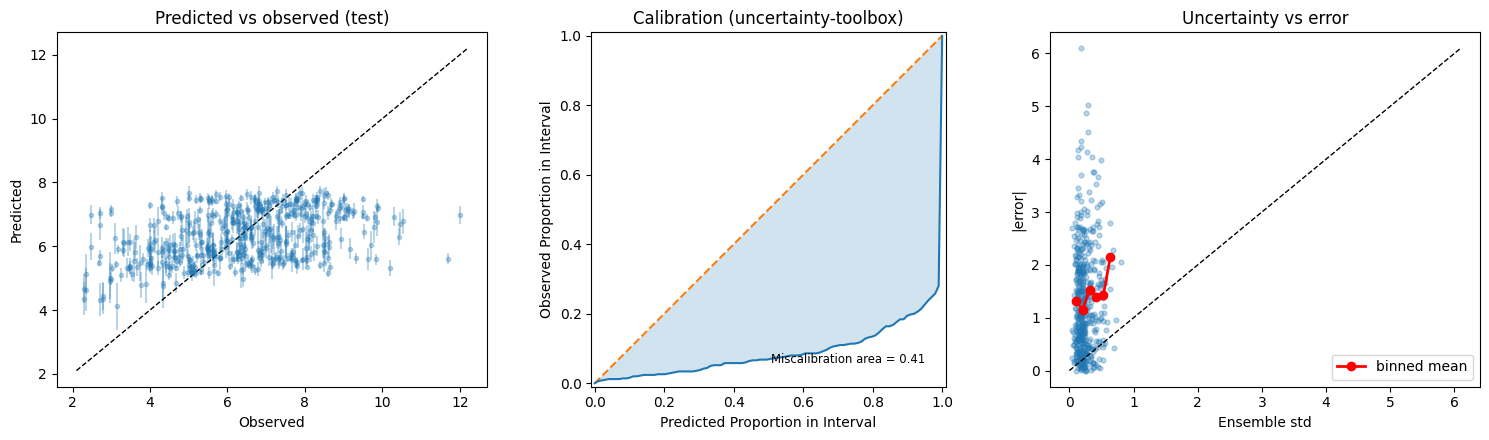

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Pred vs observed with uncertainty
ax = axes[0]
ax.errorbar(y_test, mu_test, yerr=sd_test, fmt='o', alpha=0.3, ms=3)
lim = [min(y_test.min(), mu_test.min()) - 0.2, max(y_test.max(), mu_test.max()) + 0.2]
ax.plot(lim, lim, 'k--', lw=1)
ax.set(xlabel='Observed', ylabel='Predicted', title='Predicted vs observed (test)')

# 2. uncertainty-toolbox calibration plot
ax = axes[1]
uct.viz.plot_calibration(mu_test.astype(float),
                         np.maximum(sd_test, 1e-3).astype(float),
                         y_test.astype(float),
                         ax=ax)
ax.set_title('Calibration (uncertainty-toolbox)')

# 3. Uncertainty vs |error|
ax = axes[2]
err = np.abs(mu_test - y_test)
ax.scatter(sd_test, err, alpha=0.3, s=12)
mx = max(sd_test.max(), err.max())
ax.plot([0, mx], [0, mx], 'k--', lw=1)
# binned mean
bins = np.linspace(sd_test.min(), sd_test.max(), 8)
idx = np.digitize(sd_test, bins)
xs, ys_ = [], []
for i in range(1, len(bins)):
    m = idx == i
    if m.sum() >= 3:
        xs.append((bins[i-1] + bins[i]) / 2); ys_.append(err[m].mean())
ax.plot(xs, ys_, 'r-o', lw=2, label='binned mean')
ax.set(xlabel='Ensemble std', ylabel='|error|', title='Uncertainty vs error')
ax.legend()

plt.tight_layout(); plt.savefig('v2_results.png', dpi=120); plt.show()